# Notebook to Calculate Protein Language Model Zero-Shot Scores
<img src="../data/img/plm.png" width="1200" height="400">

## Import modules

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if p.name == 'pips-design-toolkit'), None)
if repo_root is None:
    raise RuntimeError('Run this notebook from within the pips-design-toolkit repository.')
tools_dir = repo_root / "tools"
os.chdir(tools_dir)
if str(tools_dir) not in sys.path:
    sys.path.insert(0, str(tools_dir))
import pandas as pd
import numpy as np
from utils.variables import data_folder, subfolders
from utils.utils import get_pos_from_mut_list
from select_zeroshot_mutants import VariantSelection

## Specify input parameters
* *Base filename* (`data_fbase`): e.g. 'GOh1052_R1'
* *Filename suffix to be appended at the end of output file* (`fname_suffix`): e.g. '_ss'
* *Fasta filename of base sequence* (`seq_fname`): e.g. 'GOh1052.fasta'
* *Bool indicating whether to plot variant heatmap for scores across all single-site mutants* (`plot_variant_heatmap`): True or False
* *Bool indicating whether to plot histogram distribution of each set of scores across all single-site mutants* (`plot_histogram_scores`): True or False
* *List of residue integers of mutation strings to not include in final list of mutants* (`remove_mutations_or_positions`): e.g. [217, 268] or ['A156T', 'K243L']
* *Bool indicating whether remove entries with NaN values in compiled score table* (`remove_entries_with_nan`): True or False. Default: False

In [2]:
data_fbase = 'GOh1052_R1'
fname_suffix = '_ss'
seq_fname = 'GOh1052.fasta'
plot_variant_heatmap = False
plot_histogram_scores = False
remove_mutations_or_positions = [217, 268] #
remove_entries_with_nan = False

features_to_get = [
    {'name': 'Distance', 'fpath': data_folder + subfolders['conservation_and_distance'] + 'GOh1052_distance.csv', 'mut_col': 'Position', 'feature_col': ['min_distance_to_UNK', 'avg_distance_UNK'], 'wt_inc': False, 'invert_scores': False},
    {'name': 'SIFT_norm', 'fpath': data_folder + subfolders['conservation_and_distance'] + 'GOh1052_sift.csv', 'mut_col': 'Position', 'feature_col': 'sift_avg', 'wt_inc': False, 'invert_scores': False},
    {'name': 'ShannonEntropy', 'fpath': data_folder + subfolders['conservation_and_distance'] + 'GOh1052_shanms.csv', 'mut_col': 'Position', 'feature_col': ['shanID', 'shanMS'], 'wt_inc': False, 'invert_scores': False},
    {'name': 'ESM-2_LLR(-ive)', 'fpath': data_folder + subfolders['conservation_and_distance'] + 'GOh1052_esm2-33_LLRsum_entropy.csv', 'mut_col': 'mutations', 'feature_col': 'LLR', 'wt_inc': False, 'invert_scores': True},
    # {'name': 'Tango_AggVsRef', 'fpath': data_folder + subfolders['aggregation'] + 'AggregationScore_GOh1052_tango.csv', 'mut_col': 'Enzyme/Mutation', 'feature_col': 'Aggregation', 'wt_inc': True, 'invert_scores': False},
    # {'name': 'Waltz_AggVsRef', 'fpath': data_folder + subfolders['aggregation'] + 'AggregationScore_GOh1052_waltz.csv', 'mut_col': 'Enzyme/Mutation', 'feature_col': 'Aggregation', 'wt_inc': True, 'invert_scores': False},
    # {'name': 'YASARA_DDGbind', 'fpath': data_folder + subfolders['yasara'] + 'Output/' + data_fbase + '/' + 'DDGbind_GOh1052.csv', 'mut_col': 'mutations', 'feature_col': 'ebindDDG', 'wt_inc': False, 'invert_scores': False},
    # {'name': 'FoldX_DDGstability', 'fpath': data_folder + subfolders['stability'] + data_fbase + '/' + 'Output/' + data_fbase + '/' + 'DDGstability_GOh1052.csv', 'mut_col': 'Mutation', 'feature_col': 'DDG', 'wt_inc': False, 'invert_scores': False},
]

weighting_method = 'plm'  # 'uniform' #
pos_filter_dict = {
    'sift_avg': (0.15, '>', 'frac'),
    # 'min_distance_to_UNK': (5, '<', 'thres'),
}
max_variants_per_position = 5
variant_filter_dict = {
    'avg_PLM_score': (0.15, '<', 'thres'), 
    # 'Pythia_DDGstability': (0.1, '<', 'thres')
    # 'FoldX_DDGstability': (0.05, '<', 'thres'), 
    # 'Tango_AggVsRef': (0.05, '<', 'thres'),
    # 'Waltz_AggVsRef': (0.05, '<', 'thres'),
    # 'YASARA_DDGbind': (0.05, '<', 'thres'),
}

## Get zero-shot scores with PLM 
Result files are stored in: './data/mutagenesis_proposal/'

Combining scores from different calculations...
0 {'name': 'Distance', 'fpath': '../data/conservation_and_distance/GOh1052_distance.csv', 'mut_col': 'Position', 'feature_col': ['min_distance_to_UNK', 'avg_distance_UNK'], 'wt_inc': False, 'invert_scores': False}
1 {'name': 'SIFT_norm', 'fpath': '../data/conservation_and_distance/GOh1052_sift.csv', 'mut_col': 'Position', 'feature_col': 'sift_avg', 'wt_inc': False, 'invert_scores': False}
2 {'name': 'ShannonEntropy', 'fpath': '../data/conservation_and_distance/GOh1052_shanms.csv', 'mut_col': 'Position', 'feature_col': ['shanID', 'shanMS'], 'wt_inc': False, 'invert_scores': False}
3 {'name': 'ESM-2_LLR(-ive)', 'fpath': '../data/conservation_and_distance/GOh1052_esm2-33_LLRsum_entropy.csv', 'mut_col': 'mutations', 'feature_col': 'LLR', 'wt_inc': False, 'invert_scores': True}
Saved normalized scores to: ../data/mutagenesis_proposal/GOh1052_R1_AllScores.csv
Saved normalized scores to: ../data/mutagenesis_proposal/GOh1052_R1_AllScoresNorm.csv


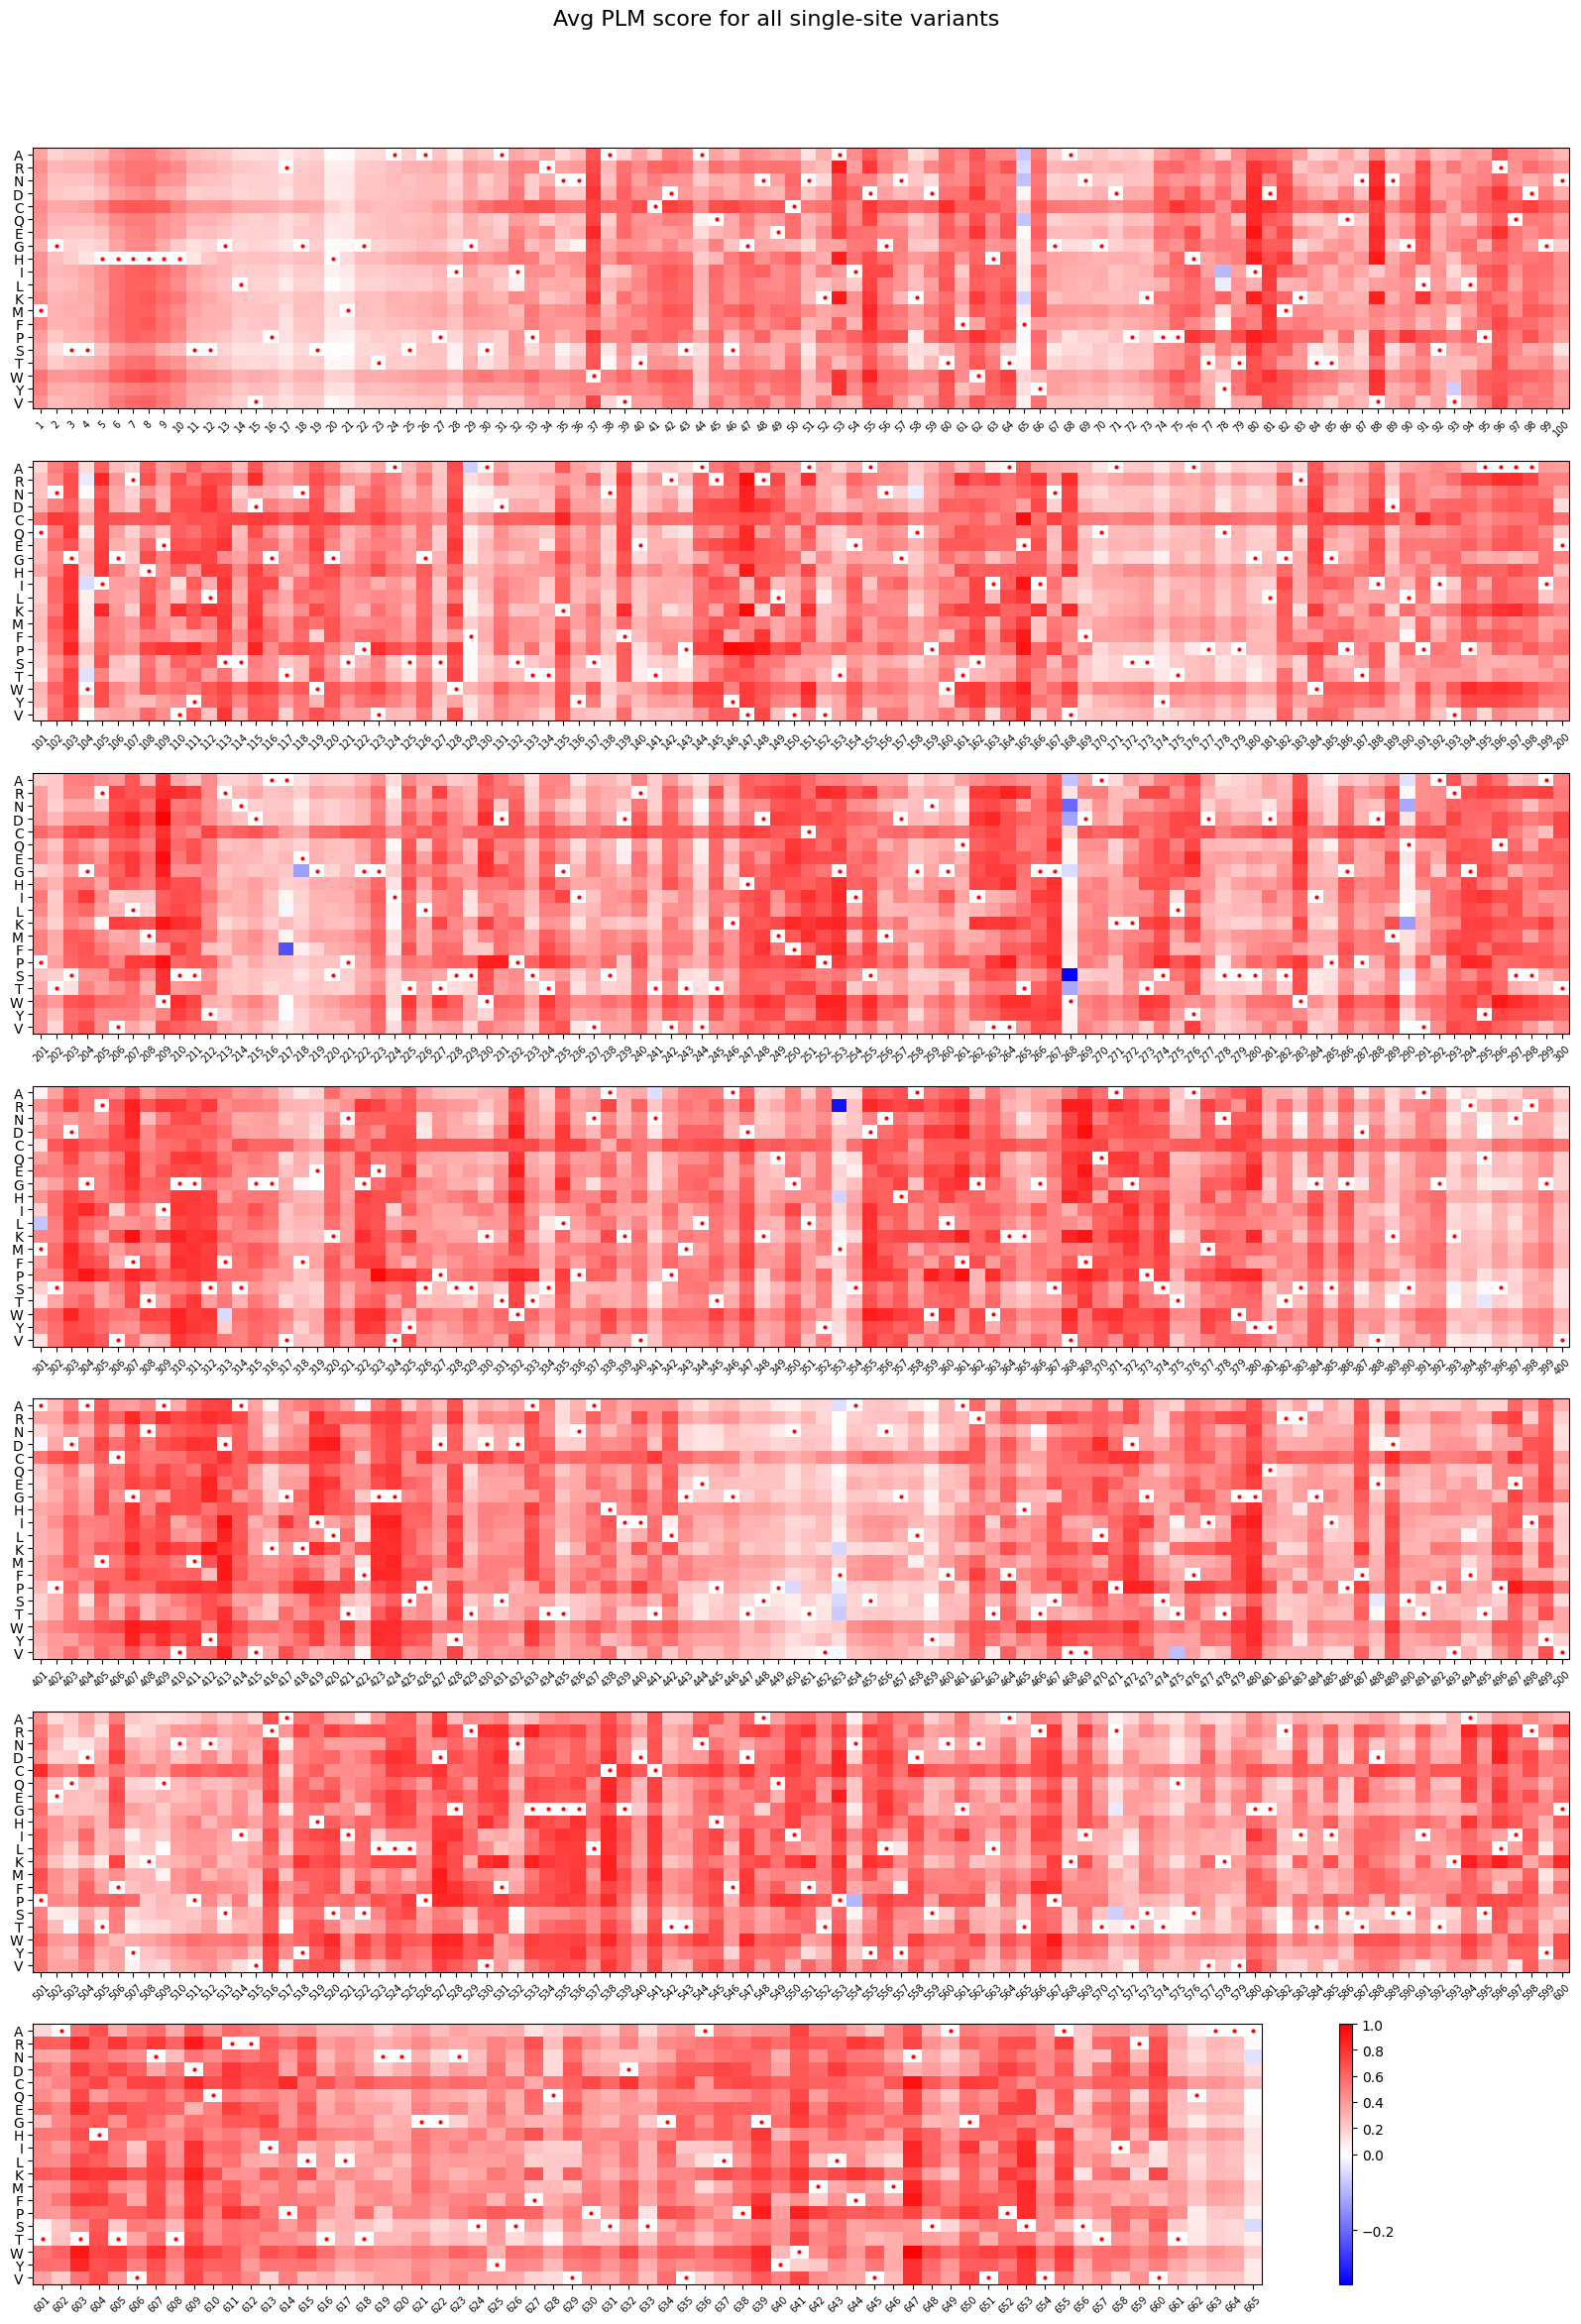

Filtering positions...
Removed 2394/12635 (18.95%) of mutations by filtering on the score: sift_avg > 0.0871
126/665 (18.95%) positions removed after filtering on conservation & structural scores: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 27, 55, 62, 95, 113, 115, 123, 124, 126, 139, 182, 184, 191, 225, 245, 247, 248, 249, 250, 251, 253, 260, 266, 267, 283, 289, 293, 294, 295, 304, 307, 310, 311, 312, 315, 320, 323, 332, 345, 347, 350, 355, 357, 360, 372, 373, 379, 386, 392, 394, 407, 413, 417, 423, 424, 428, 462, 470, 471, 473, 479, 480, 487, 497, 501, 516, 518, 519, 520, 524, 527, 534, 536, 537, 538, 541, 544, 545, 553, 555, 556, 561, 566, 567, 580, 598, 603, 604, 609, 610, 611, 612, 630, 634, 638, 639, 644, 650, 652, 653, 663, 664, 665]
539/665 positions remaining: 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71,

In [3]:
# initialize class
variant_select = VariantSelection(data_folder, data_fbase, fname_suffix, seq_fname, remove_entries_with_nan=remove_entries_with_nan)
# run selection pipeline
selected_variants = variant_select.run_ss_pipeline(
    features_to_get,
    pos_filter_dict,
    variant_filter_dict,
    max_variants_per_position,
    weighting_method,
    plot_variant_heatmap,
    plot_histogram_scores,
    remove_mutations_or_positions,
)

## Retrospective comparison of Hit Rates for screened libraries vs. selected variants
Fold change for each variant is labelled as follows: 
* Label -2: <0.3x
* Label -1: 0.3 to 0.8x
* Label 0: 0.8 to 1.2x
* Label 1: >1.2x

In [4]:
def apply_thresholds(value):
    """
    Function for thresholding data into 4-class labels
    """
    if value < 0.3:
        return -2    
    if value < 0.8:
        return -1
    elif value < 1.2:
        return 0
    else:
        return 1

### Stats for screened libraries

In [5]:
screening_data_fpath = data_folder + 'expdata/GOh1052_mutagenesis.csv'
screening_data = pd.read_csv(screening_data_fpath)[['mutations','CategoryV3', 'Fold (Max Abs)']]
screening_data['CategoryV4'] =  screening_data['Fold (Max Abs)'].apply(apply_thresholds)
N = len(screening_data)
print('FULL SCREENING DATA \nTotal N:', N)
for label in [-2,-1,0,1]:
    n_label = len(screening_data[screening_data['CategoryV4']==label])
    percent_label = round(n_label/N*100,2)
    print(f'Label {label}: {n_label} ({percent_label}%)')


FULL SCREENING DATA 
Total N: 6686
Label -2: 2529 (37.83%)
Label -1: 2767 (41.38%)
Label 0: 1359 (20.33%)
Label 1: 31 (0.46%)


### Stats for variants selected with zero-shot scores that are found in screened libraries

In [6]:
screening_data_selected = screening_data[screening_data['mutations'].isin(selected_variants['mutations'].tolist())]
N_selected = len(screening_data_selected)
percent_N_selected = round(N_selected/N*100,2)
print('SCREENING DATA FILTERED BY ZERO-SHOT SELECTIONS \nTotal N:', f'{N_selected} ({percent_N_selected}% of all screened data)')
for label in [-2,-1,0,1]:
    n_label = len(screening_data_selected[screening_data_selected['CategoryV4']==label])
    percent_label = round(n_label/N_selected*100,2)
    print(f'Label {label}: {n_label} ({percent_label}%)')

SCREENING DATA FILTERED BY ZERO-SHOT SELECTIONS 
Total N: 271 (4.05% of all screened data)
Label -2: 15 (5.54%)
Label -1: 116 (42.8%)
Label 0: 134 (49.45%)
Label 1: 6 (2.21%)


### Analyse residues corresponding to screened hits and selected variants

In [7]:
# position list for screened hits
screening_data_hits = screening_data[screening_data['CategoryV4']==1]
pos_list_hits = get_pos_from_mut_list(screening_data_hits.mutations.tolist())
print('Positions of screened hits (>1.2x):', pos_list_hits, '\n')
pos_list_sel = get_pos_from_mut_list(selected_variants.mutations.tolist())
print('Positions of selected variants (>1.2x):', pos_list_sel, '\n')
print('Overlapping positions:', [pos for pos in pos_list_sel if pos in pos_list_hits])

Positions of screened hits (>1.2x): [24, 26, 28, 157, 195, 218, 224, 226, 239, 401, 508, 542, 599, 616] 

Positions of selected variants (>1.2x): [28, 30, 32, 35, 36, 38, 44, 51, 58, 59, 65, 67, 68, 69, 71, 78, 83, 84, 87, 89, 93, 100, 101, 104, 110, 114, 125, 127, 129, 130, 134, 138, 140, 142, 143, 152, 153, 158, 163, 169, 170, 174, 176, 178, 180, 181, 183, 189, 190, 192, 200, 203, 205, 218, 224, 228, 229, 233, 236, 239, 243, 244, 258, 261, 271, 275, 278, 281, 284, 285, 290, 301, 313, 317, 318, 319, 326, 330, 334, 337, 341, 348, 353, 354, 365, 375, 383, 385, 387, 389, 393, 395, 396, 397, 400, 401, 404, 416, 422, 429, 435, 442, 444, 445, 447, 449, 450, 451, 452, 453, 454, 456, 457, 458, 459, 460, 463, 466, 474, 475, 483, 484, 485, 486, 488, 494, 495, 500, 502, 503, 504, 505, 507, 508, 509, 513, 514, 515, 517, 521, 522, 532, 551, 554, 557, 571, 572, 574, 575, 578, 582, 585, 586, 590, 591, 592, 597, 599, 601, 619, 626, 627, 628, 633, 636, 646, 656, 660, 662] 

Overlapping positions: [28,